# Phase 05.00 — Final comparison and reproducibility report

This notebook consolidates completed full-run summaries, generates the final leaderboard and charts, records immutable provenance hashes, and writes a Markdown report. It never substitutes debug results for missing full experiments.


In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path("/workspace/RoadBuddy")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("CC", "/usr/bin/gcc")
os.environ.setdefault("CXX", "/usr/bin/g++")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from roadbuddy_common import *

os.chdir(PROJECT_ROOT)
seed_everything(SEED)
ensure_dirs()
print("Project root:", PROJECT_ROOT)
print("Model revision:", MODEL_REVISION)


Project root: /workspace/RoadBuddy
Model revision: b98f263eab246eb5269ade64edbdca8a887dc44d


## 1. Completion gates


In [2]:
import matplotlib.pyplot as plt

OUTPUT_ROOT = PROJECT_ROOT / "outputs/phase05/final_report"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
status_paths = {
    "phase01": PROJECT_ROOT / "outputs/phase01/PHASE01_STATUS.json",
    "phase02": PROJECT_ROOT / "outputs/phase02/multiframe_f1_f3_f8/PHASE02_STATUS.json",
    "phase03": PROJECT_ROOT / "outputs/phase03/lora_rank_ablation/PHASE03_STATUS.json",
    "phase04": PROJECT_ROOT / "outputs/phase04/question_type_analysis/PHASE04_STATUS.json",
}
missing = [str(path) for path in status_paths.values() if not path.is_file()]
assert not missing, f"Complete all preceding phases before the final report. Missing: {missing}"
statuses = {name: json.loads(path.read_text(encoding="utf-8")) for name, path in status_paths.items()}
allowed_statuses = {"complete", "debug_complete"}
assert all(item.get("status") in allowed_statuses for item in statuses.values())
run_scopes = {item.get("run_name", "full") for item in statuses.values()}
assert len(run_scopes) == 1, f"Mixed phase scopes are not comparable: {run_scopes}"
run_scope = run_scopes.pop()
expected_status = "complete" if run_scope == "full" else "debug_complete"
assert all(item["status"] == expected_status for item in statuses.values())
print("Final report scope:", run_scope)
display(statuses)

Final report scope: debug20


{'phase01': {'phase': '01',
  'status': 'debug_complete',
  'run_name': 'debug20',
  'validation_rows': 20,
  'winner': 'zero_shot_f1',
  'winner_accuracy': 0.65,
  'model_revision': 'b98f263eab246eb5269ade64edbdca8a887dc44d',
  'seed': 42,
  'frozen_validation_ids': '/workspace/RoadBuddy/data/splits/phase01/validation_sample_ids.json'},
 'phase02': {'phase': '02',
  'status': 'debug_complete',
  'run_name': 'debug20',
  'upstream_run': 'debug20',
  'experiments': 6,
  'best_variant': 'zero_shot',
  'best_frame_count': 1,
  'best_accuracy': 0.7,
  'validation_rows': 20,
  'model_revision': 'b98f263eab246eb5269ade64edbdca8a887dc44d',
  'seed': 42},
 'phase03': {'phase': '03',
  'status': 'debug_complete',
  'run_name': 'debug20',
  'ranks': [8],
  'best_rank': 8,
  'best_accuracy': 0.65,
  'validation_rows': 20,
  'model_revision': 'b98f263eab246eb5269ade64edbdca8a887dc44d',
  'seed': 42},
 'phase04': {'phase': '04',
  'status': 'debug_complete',
  'run_name': 'debug20',
  'experiments'

## 2. Unified leaderboard


In [3]:
leaderboard_rows = []

phase01 = pd.read_csv(PROJECT_ROOT / "outputs/phase01/phase01_comparison.csv")
for _, row in phase01.iterrows():
    leaderboard_rows.append({"phase": "01", "experiment": row.experiment, "frames": 1, "rank": 0 if "zero" in row.experiment else 16, "accuracy": row.accuracy, "macro_f1": row.macro_f1, "parse_rate": row.parse_rate})

phase02 = pd.read_csv(PROJECT_ROOT / "outputs/phase02/multiframe_f1_f3_f8" / f"phase02_summary_{run_scope}.csv")
for _, row in phase02.iterrows():
    leaderboard_rows.append({"phase": "02", "experiment": f"{row.variant}_F{int(row.frame_count)}", "frames": int(row.frame_count), "rank": 0 if row.variant == "zero_shot" else 16, "accuracy": row.accuracy, "macro_f1": row.macro_f1, "parse_rate": row.parse_rate})

phase03 = pd.read_csv(PROJECT_ROOT / "outputs/phase03/lora_rank_ablation" / f"phase03_rank_summary_{run_scope}.csv")
for _, row in phase03.iterrows():
    rank = int(row["rank"])
    leaderboard_rows.append({"phase": "03", "experiment": "lora_r{}_F1".format(rank), "frames": 1, "rank": rank, "accuracy": row.accuracy, "macro_f1": row.macro_f1, "parse_rate": row.parse_rate})

leaderboard = pd.DataFrame(leaderboard_rows).drop_duplicates(subset=["experiment"], keep="last").sort_values(["accuracy", "macro_f1"], ascending=False).reset_index(drop=True)
leaderboard.insert(0, "position", np.arange(1, len(leaderboard) + 1))
leaderboard.to_csv(OUTPUT_ROOT / f"final_leaderboard_{run_scope}.csv", index=False)
display(leaderboard)

,position,phase,experiment,frames,rank,accuracy,macro_f1,parse_rate
0,1,02,zero_shot_F1,1,0,0.70,0.663690,1.0
1,2,01,zero_shot_f1,1,0,0.65,0.598485,1.0
2,3,03,lora_r8_F1,1,8,0.65,0.598485,1.0
3,4,02,zero_shot_F3,3,0,0.65,0.596667,1.0
4,5,02,lora_r16_F1,1,16,0.60,0.616228,1.0
5,6,02,zero_shot_F8,8,0,0.60,0.603535,1.0
6,7,02,lora_r16_F3,3,16,0.60,0.603535,1.0
7,8,02,lora_r16_F8,8,16,0.60,0.603535,1.0
8,9,01,lora_r16_f1,1,16,0.60,0.569444,1.0


## 3. Final charts


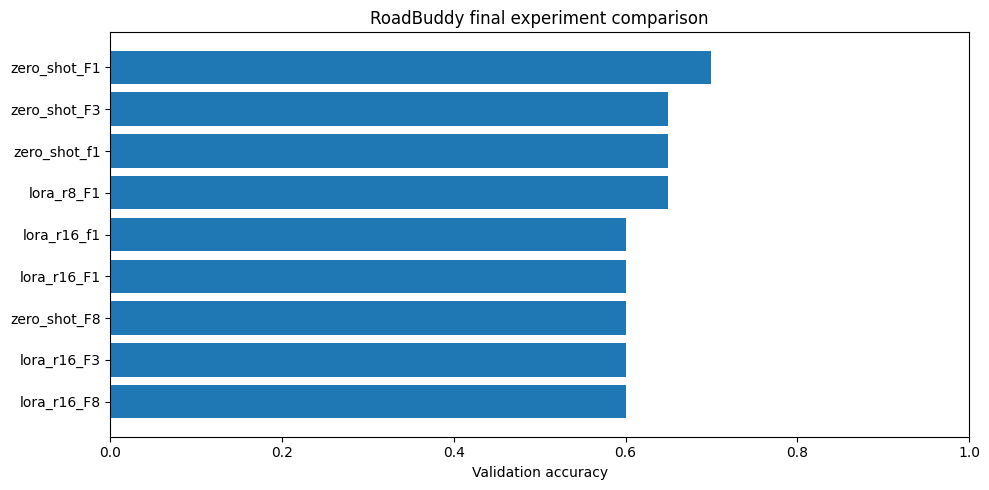

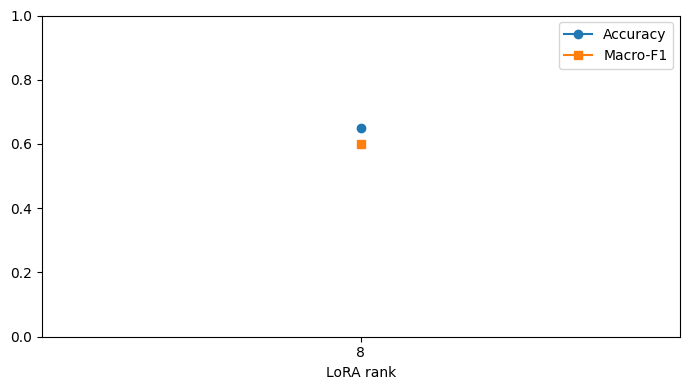

In [4]:
plot_data = leaderboard.sort_values("accuracy")
fig, ax = plt.subplots(figsize=(10, max(5, len(plot_data) * 0.42)))
ax.barh(plot_data.experiment, plot_data.accuracy)
ax.set_xlim(0, 1)
ax.set_xlabel("Validation accuracy")
ax.set_title("RoadBuddy final experiment comparison")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "final_accuracy_comparison.png", dpi=180)
plt.show()

rank_plot = phase03.sort_values("rank")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rank_plot["rank"], rank_plot.accuracy, marker="o", label="Accuracy")
ax.plot(rank_plot["rank"], rank_plot.macro_f1, marker="s", label="Macro-F1")
ax.set_xticks(rank_plot["rank"])
ax.set_ylim(0, 1)
ax.set_xlabel("LoRA rank")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "lora_rank_curve.png", dpi=180)
plt.show()


## 4. Reproducibility manifest and Markdown report


In [5]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

validation_ids_path = PATHS.phase1_split / "validation_sample_ids.json"
validation_ids_sha256 = sha256_file(validation_ids_path)
validation_rows = int(statuses["phase01"]["validation_rows"])
manifest = {
    "project_root": str(PROJECT_ROOT), "model_id": MODEL_ID, "model_revision": MODEL_REVISION,
    "seed": SEED, "flash_attention": False, "template": "Hermes-2", "run_scope": run_scope,
    "validation_ids_path": str(validation_ids_path), "validation_ids_sha256": validation_ids_sha256,
    "phase_statuses": statuses,
}
save_json(OUTPUT_ROOT / f"reproducibility_manifest_{run_scope}.json", manifest)

best = leaderboard.iloc[0]
columns = list(leaderboard.columns)
table_lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
for _, item in leaderboard.iterrows():
    values = []
    for column in columns:
        value = item[column]
        values.append(f"{value:.4f}" if isinstance(value, (float, np.floating)) else str(value))
    table_lines.append("| " + " | ".join(values) + " |")
table_md = "\n".join(table_lines)
report = f"""# RoadBuddy experiment report — {run_scope}

## Result summary

The best configuration in scope **{run_scope}** is **{best.experiment}**, with accuracy **{best.accuracy:.4f}** and macro-F1 **{best.macro_f1:.4f}** on {validation_rows} validation samples.

## Leaderboard

{table_md}

## Reproducibility contract

- Run scope: `{run_scope}`
- Model: `{MODEL_ID}`
- Revision: `{MODEL_REVISION}`
- Seed: `{SEED}`
- Native template: `Hermes-2`
- FlashAttention2: disabled
- Phase02 inner language attention: PyTorch SDPA
- Frozen validation ID SHA-256: `{validation_ids_sha256}`
- Dynamic visual token expansion: `model.num_image_token`
- Image flags: one per visual tile
- LoRA targets: `q_proj`, `k_proj`, `v_proj`, `o_proj`

## Interpretation constraints

- This report uses `{run_scope}` artifacts; it is not a full-phase claim when the scope is debug.
- Question-type slices with fewer than 20 examples are exploratory.
- All current rows have `question_type=unknown`, so type-specific conclusions are unavailable.
- Frame-count and rank conclusions apply only to this frozen prediction subset and model revision.
"""
report_path = OUTPUT_ROOT / f"ROADBUDDY_REPORT_{run_scope}.md"
report_path.write_text(report, encoding="utf-8")
phase_status = "complete" if run_scope == "full" else "debug_complete"
save_json(OUTPUT_ROOT / "PHASE05_STATUS.json", {
    "phase": "05", "status": phase_status, "run_name": run_scope,
    "best_experiment": best.experiment, "best_accuracy": float(best.accuracy),
    "validation_rows": validation_rows,
    "model_revision": MODEL_REVISION, "seed": SEED,
})
print("Final report:", report_path)

Final report: /workspace/RoadBuddy/outputs/phase05/final_report/ROADBUDDY_REPORT_debug20.md
